# SIS 1: Population and Area of Countries
**Course:** Data Collection & Preparation · **Student:** Tursyn Nurbolat Shokanuly · **Individual project**

**Research question:** How is country/economy population associated with surface area, and which places have the largest populations, areas and estimated densities?

**Sources:**
1. World Bank API country metadata: https://api.worldbank.org/v2/country
2. World Bank API population indicator: https://api.worldbank.org/v2/country/all/indicator/SP.POP.TOTL (observation year **2024**)
3. Static HTML: https://www.scrapethissite.com/pages/simple/ (country cards with area and population).

The API supplies population; the webpage supplies area. Metadata and flag CSS classes supply two-letter country codes for a logical join. Scope includes economies and territories as well as sovereign countries. The webpage does not specify the reference year or methodology for area/population, so density is an **approximate cross-source measure**. This is a descriptive study, not evidence of causation.

## 1. Setup
Run all cells from top to bottom. Install dependencies with `pip install -r requirements.txt` if needed. `LIVE=True` recollects real data and saves snapshots; `LIVE=False` replays the included snapshots, explicitly identified as offline data. Nothing is fabricated if a request fails.


In [1]:
import json, time, re, hashlib
from pathlib import Path
from datetime import datetime, timezone
from urllib.parse import urlparse
from urllib.robotparser import RobotFileParser
import requests
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
from IPython.display import display, Image
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

LIVE = True  # Change to False only to replay saved source snapshots.
YEAR = 2024
API_BASE = "https://api.worldbank.org/v2"
PAGE_URL = "https://www.scrapethissite.com/pages/simple/"
AGENT = "SISCountryStudy/1.0"
DATA = Path("data"); RAW = Path("raw_data"); FIG = Path("figures")
for folder in [DATA,RAW,FIG]: folder.mkdir(exist_ok=True)
session = requests.Session()
session.headers.update({"User-Agent": "Mozilla/5.0 " + AGENT})
session.mount("https://", HTTPAdapter(max_retries=Retry(total=3,backoff_factor=1,status_forcelist=[429,500,502,503,504])))
plt.rcParams.update({"font.family":"DejaVu Sans","font.size":10,"axes.spines.top":False,"axes.spines.right":False})
COLLECTED = datetime.now(timezone.utc).isoformat()
provenance = []
print("Mode:","LIVE collection" if LIVE else "OFFLINE snapshot replay")
print("Execution time UTC:",COLLECTED)
print("API population year:",YEAR)


Mode: LIVE collection
Execution time UTC: 2026-10-08T21:53:58.494419+00:00
API population year: 2024


## 2. Collect API data
The JSON schema is `[pagination dictionary, list of records]`. Check HTTP status **and** JSON shape. A 200 HTTP status alone cannot prove that the response contains usable data. `per_page=100` and `page` are used to collect all pages.

In [2]:
def get_api_page(path, params, snapshot_name):
    snapshot = RAW / snapshot_name
    if LIVE:
        response = session.get(API_BASE+path,params={"format":"json",**params},timeout=60)
        print("API status:",response.status_code,"URL:",response.url)
        response.raise_for_status()
        payload = response.json()
    else:
        payload = json.loads(snapshot.read_text(encoding="utf-8"))
        print("OFFLINE API snapshot:",snapshot)
    if not (isinstance(payload,list) and len(payload)==2 and isinstance(payload[0],dict) and isinstance(payload[1],list)):
        raise ValueError(f"Unexpected API response: {str(payload)[:300]}")
    if LIVE:
        snapshot.write_text(json.dumps(payload,ensure_ascii=False,indent=2),encoding="utf-8")
        provenance.append({"source":"World Bank","url":response.url,"status":response.status_code,
                           "collected_utc":datetime.now(timezone.utc).isoformat(),"snapshot":str(snapshot),
                           "sha256":hashlib.sha256(snapshot.read_bytes()).hexdigest()})
    return payload

def collect_api(path, stem, params=None):
    params = params or {}
    first = get_api_page(path,{**params,"per_page":100,"page":1},f"{stem}_page_1.json")
    records = list(first[1])
    for page in range(2,int(first[0]["pages"])+1):
        if LIVE: time.sleep(0.2)
        part = get_api_page(path,{**params,"per_page":100,"page":page},f"{stem}_page_{page}.json")
        records.extend(part[1])
    assert len(records)==int(first[0]["total"]),"Incomplete API pagination"
    return first[0],records

meta_header, metadata = collect_api("/country","country")
pop_header, observations = collect_api("/country/all/indicator/SP.POP.TOTL","population",{"date":YEAR})
print("Metadata records:",len(metadata),"Population observations:",len(observations))
print("Population source last updated:",pop_header.get("lastupdated"))
print("Country JSON example:",json.dumps(metadata[0],indent=2))
print("Population JSON example:",json.dumps(observations[0],indent=2))


API status: 200 URL: https://api.worldbank.org/v2/country?format=json&per_page=100&page=1
API status: 200 URL: https://api.worldbank.org/v2/country?format=json&per_page=100&page=2
API status: 200 URL: https://api.worldbank.org/v2/country?format=json&per_page=100&page=3
API status: 200 URL: https://api.worldbank.org/v2/country/all/indicator/SP.POP.TOTL?format=json&date=2024&per_page=100&page=1
API status: 200 URL: https://api.worldbank.org/v2/country/all/indicator/SP.POP.TOTL?format=json&date=2024&per_page=100&page=2
API status: 200 URL: https://api.worldbank.org/v2/country/all/indicator/SP.POP.TOTL?format=json&date=2024&per_page=100&page=3
Metadata records: 296 Population observations: 266
Population source last updated: 2026-10-08
Country JSON example: {
  "id": "ABW",
  "iso2Code": "AW",
  "name": "Aruba",
  "region": {
    "id": "LCN",
    "iso2code": "ZJ",
    "value": "Latin America & Caribbean "
  },
  "adminregion": {
    "id": "",
    "iso2code": "",
    "value": ""
  },
  "inc

In [3]:
metadata_raw = pd.DataFrame([{
    "iso3":r.get("id"),"iso2":r.get("iso2Code"),"country_api":r.get("name"),
    "capital_api":r.get("capitalCity"),"region_id":r.get("region",{}).get("id"),
    "region":r.get("region",{}).get("value"),"income_level":r.get("incomeLevel",{}).get("value")
} for r in metadata])
population_raw = pd.DataFrame([{"iso3":r.get("countryiso3code"),"year":r.get("date"),"population_2024":r.get("value")} for r in observations])
display(metadata_raw.head())
display(population_raw.head())


,iso3,iso2,country_api,capital_api,region_id,region,income_level
0,ABW,AW,Aruba,Oranjestad,LCN,Latin America & Caribbean,High income
1,AFE,ZH,Africa Eastern and Southern,,NA,Aggregates,Aggregates
2,AFG,AF,Afghanistan,Kabul,MEA,"Middle East, North Africa, Afghanistan & Pakistan",Low income
3,AFR,A9,Africa,,NA,Aggregates,Aggregates
4,AFW,ZI,Africa Western and Central,,NA,Aggregates,Aggregates


,iso3,year,population_2024
0,AFE,2024,769280888.0
1,AFW,2024,520655398.0
2,ARB,2024,492612632.0
3,CSS,2024,4539060.0
4,CEB,2024,100061963.0


## 3. Clean API data
Remove aggregates (`region.id == 'NA'`) so regional totals are not treated as countries. Population observations are filtered to the remaining country IDs before the join. Convert types, strip text and preserve missing data. Country codes must be unique. ISO2/code-like values are used as supplied by the sources; special territorial codes are not assumed to be official ISO assignments.

In [4]:
api_df = metadata_raw.loc[metadata_raw["region_id"].ne("NA")].drop(columns="region_id").copy()
for col in api_df.columns:
    api_df[col] = api_df[col].astype("string").str.strip().replace("",pd.NA)
api_df["iso2"] = api_df["iso2"].str.upper()
print("Removed aggregate metadata records:",len(metadata_raw)-len(api_df))
print("Duplicate metadata ISO3:",int(api_df["iso3"].duplicated().sum()))
api_df = api_df.drop_duplicates("iso3").reset_index(drop=True)
assert api_df["iso3"].notna().all() and api_df["iso2"].notna().all()
assert not api_df["iso2"].duplicated().any()
population_df = population_raw.loc[population_raw["iso3"].isin(api_df["iso3"])].copy()
population_df["year"] = pd.to_numeric(population_df["year"],errors="raise").astype("Int64")
population_df["population_2024"] = pd.to_numeric(population_df["population_2024"],errors="coerce").astype("Int64")
print("Duplicate population ISO3/year:",int(population_df.duplicated(["iso3","year"]).sum()))
population_df = population_df.drop_duplicates(["iso3","year"])
assert not population_df["iso3"].duplicated().any()
api_df = api_df.merge(population_df,on="iso3",how="left",validate="one_to_one")
assert api_df["year"].dropna().eq(YEAR).all()
# The year describes the requested population period even if its value is missing.
api_df["year"] = api_df["year"].fillna(YEAR)
assert api_df["population_2024"].dropna().ge(0).all()
api_df = api_df.sort_values("country_api").reset_index(drop=True)
api_df.to_csv(DATA/"countries_api.csv",index=False)
print("Clean API shape:",api_df.shape)
display(pd.DataFrame({"dtype":api_df.dtypes.astype(str),"missing":api_df.isna().sum()}))
display(api_df.head(8))


Removed aggregate metadata records: 79
Duplicate metadata ISO3: 0
Duplicate population ISO3/year: 0
Clean API shape: (217, 8)


,dtype,missing
iso3,object,0
iso2,string,0
country_api,string,0
capital_api,string,6
region,string,0
income_level,string,0
year,Int64,0
population_2024,Int64,0


,iso3,iso2,country_api,capital_api,region,income_level,year,population_2024
0,AFG,AF,Afghanistan,Kabul,"Middle East, North Africa, Afghanistan & Pakistan",Low income,2024,42647492
1,ALB,AL,Albania,Tirane,Europe & Central Asia,Upper middle income,2024,2377128
2,DZA,DZ,Algeria,Algiers,"Middle East, North Africa, Afghanistan & Pakistan",Upper middle income,2024,46814308
3,ASM,AS,American Samoa,Pago Pago,East Asia & Pacific,High income,2024,46765
4,AND,AD,Andorra,Andorra la Vella,Europe & Central Asia,High income,2024,81938
5,AGO,AO,Angola,Luanda,Sub-Saharan Africa,Lower middle income,2024,37885849
6,ATG,AG,Antigua and Barbuda,Saint John's,Latin America & Caribbean,High income,2024,93772
7,ARG,AR,Argentina,Buenos Aires,Latin America & Caribbean,Upper middle income,2024,45696159


## 4. Check robots.txt and scrape static HTML
Request robots.txt first. A disallow rule or an unavailable robots policy stops live scraping; a 404 means no published robots rules. Cache the checked policy and page for transparent offline replay. The site is a learning sandbox.

Country codes are extracted from flag classes, e.g. `flag-icon-ad` -> `AD`. This avoids joining different entities using vague name similarity. The page itself supplies this code; no separate country-code library is used. A missing/broken flag code is recovered only from a unique exact normalized API name, and the repair is printed.

In [5]:
robots_url = "https://www.scrapethissite.com/robots.txt"
if LIVE:
    robots_response = session.get(robots_url,timeout=60)
    print("robots.txt status:",robots_response.status_code)
    if robots_response.status_code not in [200,404]:
        raise RuntimeError("Cannot verify robots policy; stop scraping")
    robot = RobotFileParser(); robot.set_url(robots_url)
    robot.parse(robots_response.text.splitlines() if robots_response.status_code==200 else [])
    if not robot.can_fetch(AGENT,PAGE_URL) or not robot.can_fetch(session.headers["User-Agent"],PAGE_URL):
        raise RuntimeError("robots.txt does not permit this request")
    (RAW/"robots.txt").write_text(robots_response.text if robots_response.status_code==200 else "",encoding="utf-8")
    provenance.append({"source":"robots policy","url":robots_url,"status":robots_response.status_code,"collected_utc":datetime.now(timezone.utc).isoformat(),"snapshot":str(RAW/"robots.txt")})
    time.sleep(1)
    page = session.get(PAGE_URL,timeout=60)
    print("Webpage status:",page.status_code)
    page.raise_for_status()
    html = page.text
    (RAW/"countries.html").write_text(html,encoding="utf-8")
    provenance.append({"source":"Scrape This Site","url":page.url,"status":page.status_code,"collected_utc":datetime.now(timezone.utc).isoformat(),"snapshot":str(RAW/"countries.html"),"sha256":hashlib.sha256((RAW/"countries.html").read_bytes()).hexdigest()})
else:
    html = (RAW/"countries.html").read_text(encoding="utf-8")
    print("OFFLINE replay: no live HTTP requests; the saved robots policy describes the original collection.")
soup = BeautifulSoup(html,"html.parser")
cards = soup.select("div.country")
if not cards: raise ValueError("No country cards found; HTML structure may have changed")
print("Page title:",soup.title.get_text(strip=True))
print("Cards:",len(cards)); print(cards[0].prettify()[:1100])


robots.txt status: 200
Webpage status: 200
Page title: Countries of the World: A Simple Example | Scrape This Site | A public sandbox for learning web scraping
Cards: 250
<div class="col-md-4 country">
 <h3 class="country-name">
  <i class="flag-icon flag-icon-ad">
  </i>
  Andorra
 </h3>
 <div class="country-info">
  <strong>
   Capital:
  </strong>
  <span class="country-capital">
   Andorra la Vella
  </span>
  <br/>
  <strong>
   Population:
  </strong>
  <span class="country-population">
   84000
  </span>
  <br/>
  <strong>
   Area (km
   <sup>
    2
   </sup>
   ):
  </strong>
  <span class="country-area">
   468.0
  </span>
  <br/>
 </div>
</div>



In [6]:
def text_of(card,selector):
    tag = card.select_one(selector)
    return tag.get_text(strip=True) if tag else None

def flag_code(card):
    flag = card.select_one("i.flag-icon")
    for cls in flag.get("class",[]) if flag else []:
        match = re.fullmatch(r"flag-icon-([a-z]{2})",cls)
        if match: return match.group(1).upper()
    return None

scraped_raw = pd.DataFrame([{
    "iso2":flag_code(card),"country_web":text_of(card,".country-name"),
    "capital_web":text_of(card,".country-capital"),
    "population_web":text_of(card,".country-population"),"area_km2":text_of(card,".country-area")
} for card in cards])
web_df = scraped_raw.copy()
for col in web_df.columns:
    web_df[col] = web_df[col].astype("string").str.strip().replace({"":pd.NA,"None":pd.NA})
web_df["population_web"] = pd.to_numeric(web_df["population_web"],errors="coerce").astype("Int64")
web_df["area_km2"] = pd.to_numeric(web_df["area_km2"],errors="coerce").astype("Float64")
# Recover missing flag codes only through a unique exact normalized API name.
missing_codes = web_df["iso2"].isna()
print("Missing flag-code records:",web_df.loc[missing_codes,"country_web"].tolist())
name_to_code = api_df.assign(name_key=api_df["country_api"].str.casefold().str.strip())
assert not name_to_code["name_key"].duplicated().any()
name_to_code = name_to_code.set_index("name_key")["iso2"]
recovered = web_df.loc[missing_codes,"country_web"].str.casefold().str.strip().map(name_to_code)
print("Exact-name code recovery:",dict(zip(web_df.loc[missing_codes,"country_web"],recovered)))
web_df.loc[missing_codes,"iso2"] = recovered
print("Web duplicate rows:",int(web_df.duplicated().sum()))
print("Web duplicate codes:",int(web_df["iso2"].duplicated().sum()))
web_df = web_df.drop_duplicates().reset_index(drop=True)
assert web_df["iso2"].notna().all() and not web_df["iso2"].duplicated().any()
assert web_df["country_web"].notna().all()
assert web_df["area_km2"].dropna().ge(0).all()
assert web_df["population_web"].dropna().ge(0).all()
web_df.to_csv(DATA/"countries_scraped.csv",index=False)
print("Clean webpage shape:",web_df.shape)
display(pd.DataFrame({"dtype":web_df.dtypes.astype(str),"missing":web_df.isna().sum()}))
display(web_df.head(8))
if LIVE:
    (RAW/"provenance.json").write_text(json.dumps(provenance,indent=2),encoding="utf-8")
print("Original collection provenance:")
display(pd.DataFrame(json.loads((RAW/"provenance.json").read_text(encoding="utf-8")))[["source","status","collected_utc"]])


Missing flag-code records: ['Norway']
Exact-name code recovery: {'Norway': 'NO'}
Web duplicate rows: 0
Web duplicate codes: 0
Clean webpage shape: (250, 5)
Original collection provenance:


,dtype,missing
iso2,string,0
country_web,string,0
capital_web,string,8
population_web,Int64,0
area_km2,Float64,0


,iso2,country_web,capital_web,population_web,area_km2
0,AD,Andorra,Andorra la Vella,84000,468.0
1,AE,United Arab Emirates,Abu Dhabi,4975593,82880.0
2,AF,Afghanistan,Kabul,29121286,647500.0
3,AG,Antigua and Barbuda,St. John's,86754,443.0
4,AI,Anguilla,The Valley,13254,102.0
5,AL,Albania,Tirana,2986952,28748.0
6,AM,Armenia,Yerevan,2968000,29800.0
7,AO,Angola,Luanda,13068161,1246700.0


,source,status,collected_utc
0,World Bank,200,2026-10-08T21:54:05.715748+00:00
1,World Bank,200,2026-10-08T21:54:05.974541+00:00
2,World Bank,200,2026-10-08T21:54:06.241975+00:00
3,World Bank,200,2026-10-08T21:54:06.402239+00:00
4,World Bank,200,2026-10-08T21:54:06.672886+00:00
5,World Bank,200,2026-10-08T21:54:07.016405+00:00
6,robots policy,200,2026-10-08T21:54:14.913493+00:00
7,Scrape This Site,200,2026-10-08T21:54:16.231253+00:00


## 5. Merge and transform
Join country codes with `validate='one_to_one'`. An outer audit shows matched and unmatched records. Only matched records are analysed. Print pairs of different country names so code alignment can be inspected. For example, World Bank abbreviations need not equal the webpage names.

Derived columns: population in millions, area in millions of km², and estimated population density (people/km²). For density and correlations, require positive area and positive nonmissing population. Do not turn an unknown population into zero.

In [7]:
audit = api_df.merge(web_df,on="iso2",how="outer",indicator=True,validate="one_to_one")
print("Merge audit:");print(audit["_merge"].value_counts().to_string())
unmatched = audit.loc[audit["_merge"].ne("both"),["iso2","country_api","country_web","_merge"]]
display(unmatched)
unmatched.to_csv(DATA/"unmatched_codes.csv",index=False)
merged = audit.loc[audit["_merge"].eq("both")].drop(columns="_merge").copy()
merged = merged.rename(columns={"country_api":"country"}).sort_values("country").reset_index(drop=True)
name_differences = merged.loc[merged["country"].str.casefold().ne(merged["country_web"].str.casefold()),["iso2","country","country_web"]]
print("Different name strings for matched codes:");display(name_differences)
excluded = merged.loc[merged["population_2024"].isna() | merged["population_2024"].le(0) | merged["area_km2"].isna() | merged["area_km2"].le(0)]
print("Excluded from positive-value EDA:",len(excluded));display(excluded[["iso2","country","population_2024","area_km2"]])
analysis = merged.loc[merged["population_2024"].gt(0) & merged["area_km2"].gt(0)].copy()
analysis["population_millions"] = analysis["population_2024"].astype(float)/1_000_000
analysis["area_million_km2"] = analysis["area_km2"].astype(float)/1_000_000
analysis["estimated_density"] = analysis["population_2024"].astype(float)/analysis["area_km2"].astype(float)
analysis["log10_population"] = np.log10(analysis["population_2024"].astype(float))
analysis["log10_area"] = np.log10(analysis["area_km2"].astype(float))
merged.to_csv(DATA/"countries_merged.csv",index=False)
analysis.to_csv(DATA/"countries_analysis.csv",index=False)
print("Matched rows:",len(merged),"EDA rows:",len(analysis))
display(analysis[["iso2","country","region","population_2024","area_km2","estimated_density"]].head(10))


Merge audit:
_merge
both          216
right_only     34
left_only       1
Different name strings for matched codes:
Excluded from positive-value EDA: 0
Matched rows: 216 EDA rows: 216


,iso2,country_api,country_web,_merge
4,AI,<NA>,Anguilla,right_only
8,AQ,<NA>,Antarctica,right_only
14,AX,<NA>,Åland,right_only
25,BL,<NA>,Saint Barthélemy,right_only
29,BQ,<NA>,Bonaire,right_only
33,BV,<NA>,Bouvet Island,right_only
38,CC,<NA>,Cocos [Keeling] Islands,right_only
44,CK,<NA>,Cook Islands,right_only
53,CX,<NA>,Christmas Island,right_only
65,EH,<NA>,Western Sahara,right_only


,iso2,country,country_web
13,BS,"Bahamas, The",Bahamas
28,BN,Brunei Darussalam,Brunei
32,CV,Cabo Verde,Cape Verde
43,CD,"Congo, Dem. Rep.",Democratic Republic of the Congo
44,CG,"Congo, Rep.",Republic of the Congo
46,CI,Cote d'Ivoire,Ivory Coast
51,CZ,Czechia,Czech Republic
57,EG,"Egypt, Arab Rep.",Egypt
62,SZ,Eswatini,Swaziland
70,GM,"Gambia, The",Gambia


,iso2,country,population_2024,area_km2


,iso2,country,region,population_2024,area_km2,estimated_density
0,AF,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",42647492,647500.0,65.864853
1,AL,Albania,Europe & Central Asia,2377128,28748.0,82.688465
2,DZ,Algeria,"Middle East, North Africa, Afghanistan & Pakistan",46814308,2381740.0,19.655507
3,AS,American Samoa,East Asia & Pacific,46765,199.0,235.000000
4,AD,Andorra,Europe & Central Asia,81938,468.0,175.081197
5,AO,Angola,Sub-Saharan Africa,37885849,1246700.0,30.388906
6,AG,Antigua and Barbuda,Latin America & Caribbean,93772,443.0,211.674944
7,AR,Argentina,Latin America & Caribbean,45696159,2766890.0,16.515351
8,AM,Armenia,Europe & Central Asia,3033500,29800.0,101.795302
9,AW,Aruba,Latin America & Caribbean,107995,193.0,559.559585


## 6. Exploratory data analysis
`describe()` summarizes count, mean, standard deviation, quartiles and range. Pearson correlation measures linear association and is sensitive to large countries. Spearman correlation compares ranks and can describe monotonic association. Pearson on log-transformed variables summarizes proportional size patterns. None proves that area causes population.

In [8]:
stats = analysis[["population_2024","area_km2","estimated_density"]].astype(float).describe()
display(stats.round(2));stats.to_csv(DATA/"descriptive_statistics.csv")
x = analysis["area_km2"].astype(float); y = analysis["population_2024"].astype(float)
pearson = x.corr(y)
# Spearman = Pearson correlation of average ranks. This avoids an optional SciPy dependency.
spearman = x.rank(method="average").corr(y.rank(method="average"))
log_pearson = analysis["log10_area"].corr(analysis["log10_population"])
correlations = pd.DataFrame({"measure":["Pearson (raw)","Spearman (ranks)","Pearson (log10)"],"correlation":[pearson,spearman,log_pearson],"n":[len(analysis)]*3})
display(correlations.round(4));correlations.to_csv(DATA/"correlations.csv",index=False)
print("No p-values or causal claims: this is a descriptive cross-country comparison.")
print("API region coverage:");display(analysis.groupby("region",observed=True).agg(records=("iso3","count"),median_density=("estimated_density","median")).round(2))


No p-values or causal claims: this is a descriptive cross-country comparison.
API region coverage:


,population_2024,area_km2,estimated_density
count,2.160000e+02,216.00,216.00
mean,3.758017e+07,626944.49,388.48
std,1.431410e+08,1828731.85,1607.17
min,9.646000e+03,1.95,0.03
25%,8.577428e+05,10970.25,38.95
50%,6.751308e+06,95755.00,96.81
75%,2.707288e+07,465990.00,237.54
max,1.450936e+09,17100000.00,19810.77


,measure,correlation,n
0,Pearson (raw),0.4444,216
1,Spearman (ranks),0.8356,216
2,Pearson (log10),0.8690,216


,records,median_density
region,,
East Asia & Pacific,37,139.27
Europe & Central Asia,57,82.69
Latin America & Caribbean,42,104.31
"Middle East, North Africa, Afghanistan & Pakistan",23,116.37
North America,3,35.31
South Asia,6,387.69
Sub-Saharan Africa,48,64.36


## 7. Visualizations
Four labeled plots. Top lists refer to the matched analysis sample, not all possible territories worldwide. Bar charts start at zero; the scatter uses log axes because country sizes span several orders of magnitude.

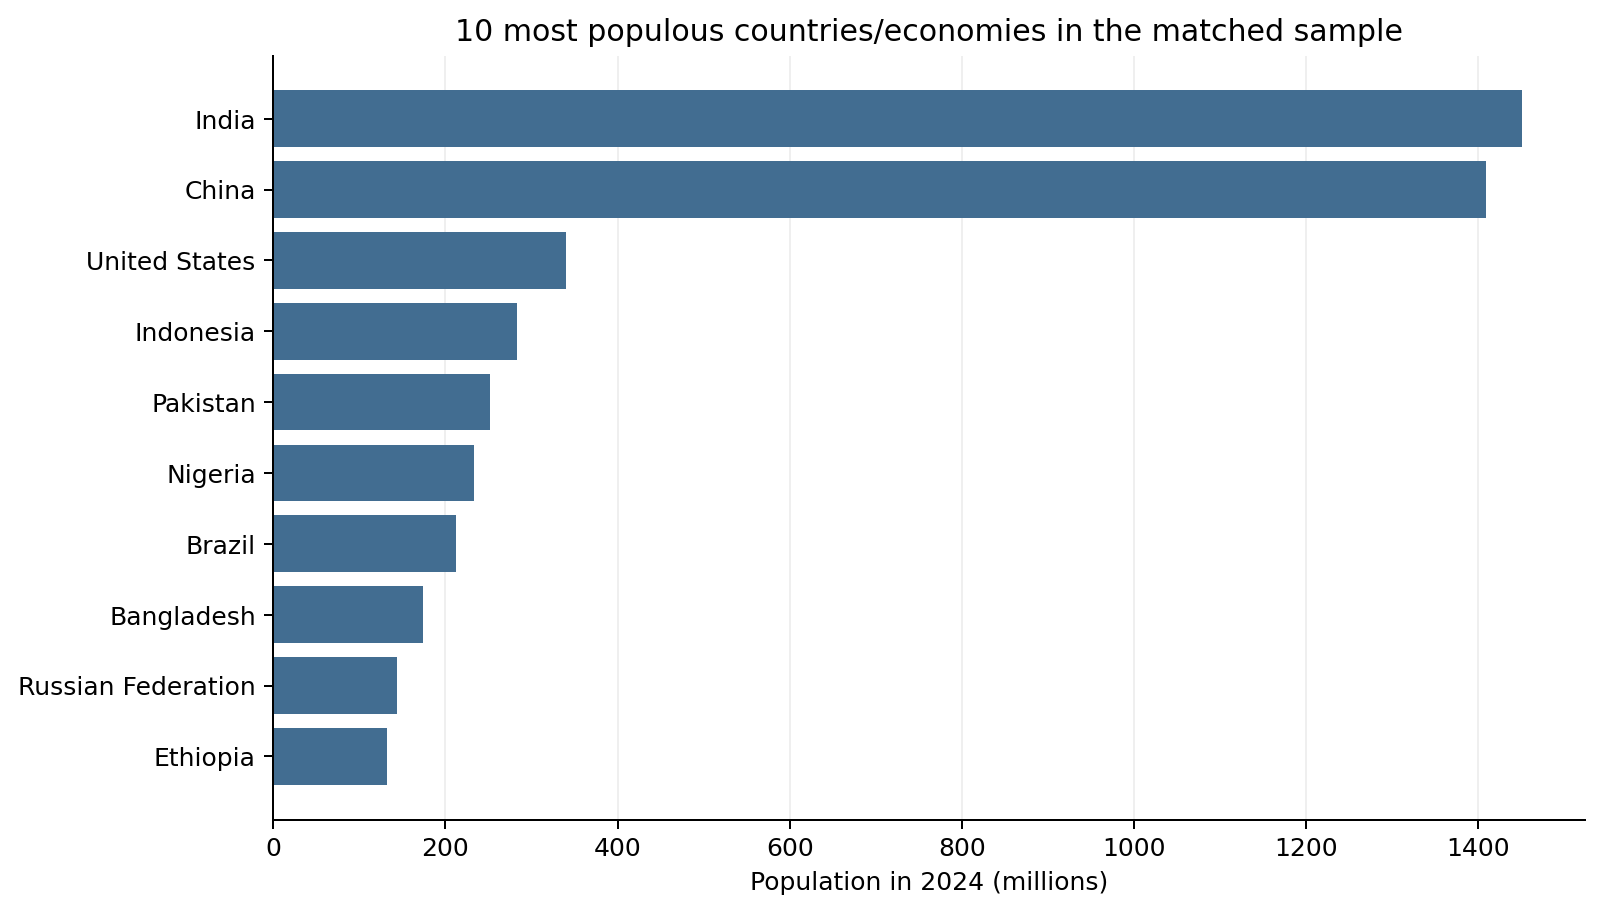

In [9]:
def save_plot(fig,name):
    fig.tight_layout()
    fig.savefig(FIG/name,dpi=180,bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=str(FIG/name)))

top_pop = analysis.nlargest(10,"population_2024").sort_values("population_2024")
fig,ax = plt.subplots(figsize=(9,5.2))
ax.barh(top_pop["country"],top_pop["population_millions"],color="#426d91")
ax.set(xlabel="Population in 2024 (millions)",title="10 most populous countries/economies in the matched sample")
ax.grid(axis="x",alpha=.2);ax.set_axisbelow(True)
save_plot(fig,"01_top_population.png")


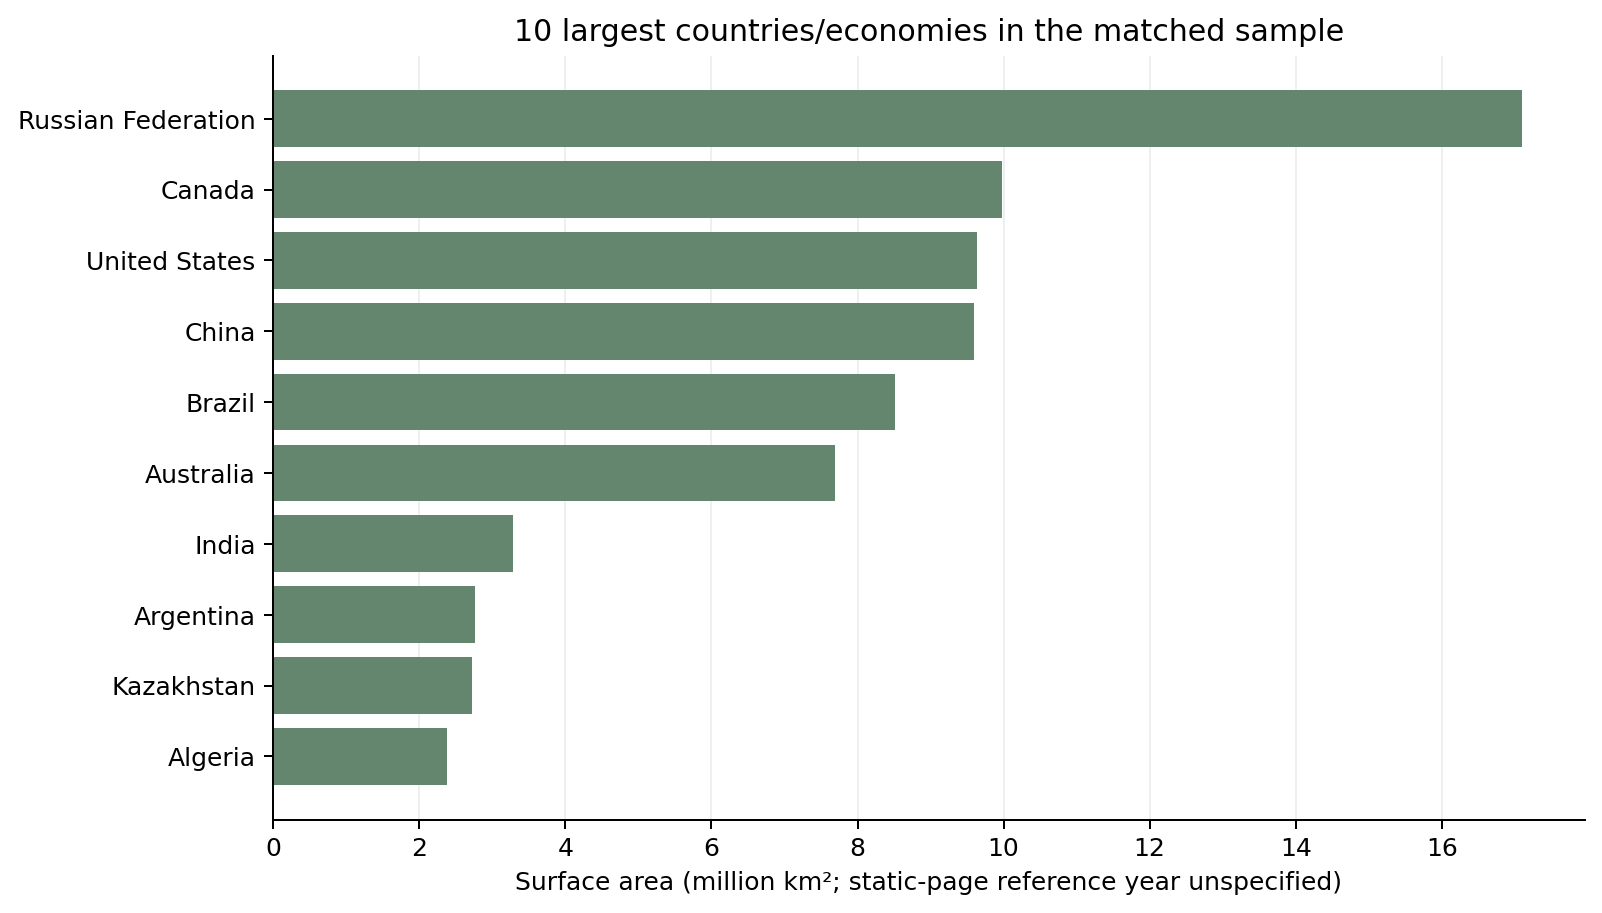

In [10]:
top_area = analysis.nlargest(10,"area_km2").sort_values("area_km2")
fig,ax = plt.subplots(figsize=(9,5.2))
ax.barh(top_area["country"],top_area["area_million_km2"],color="#64866e")
ax.set(xlabel="Surface area (million km²; static-page reference year unspecified)",title="10 largest countries/economies in the matched sample")
ax.grid(axis="x",alpha=.2);ax.set_axisbelow(True)
save_plot(fig,"02_top_area.png")


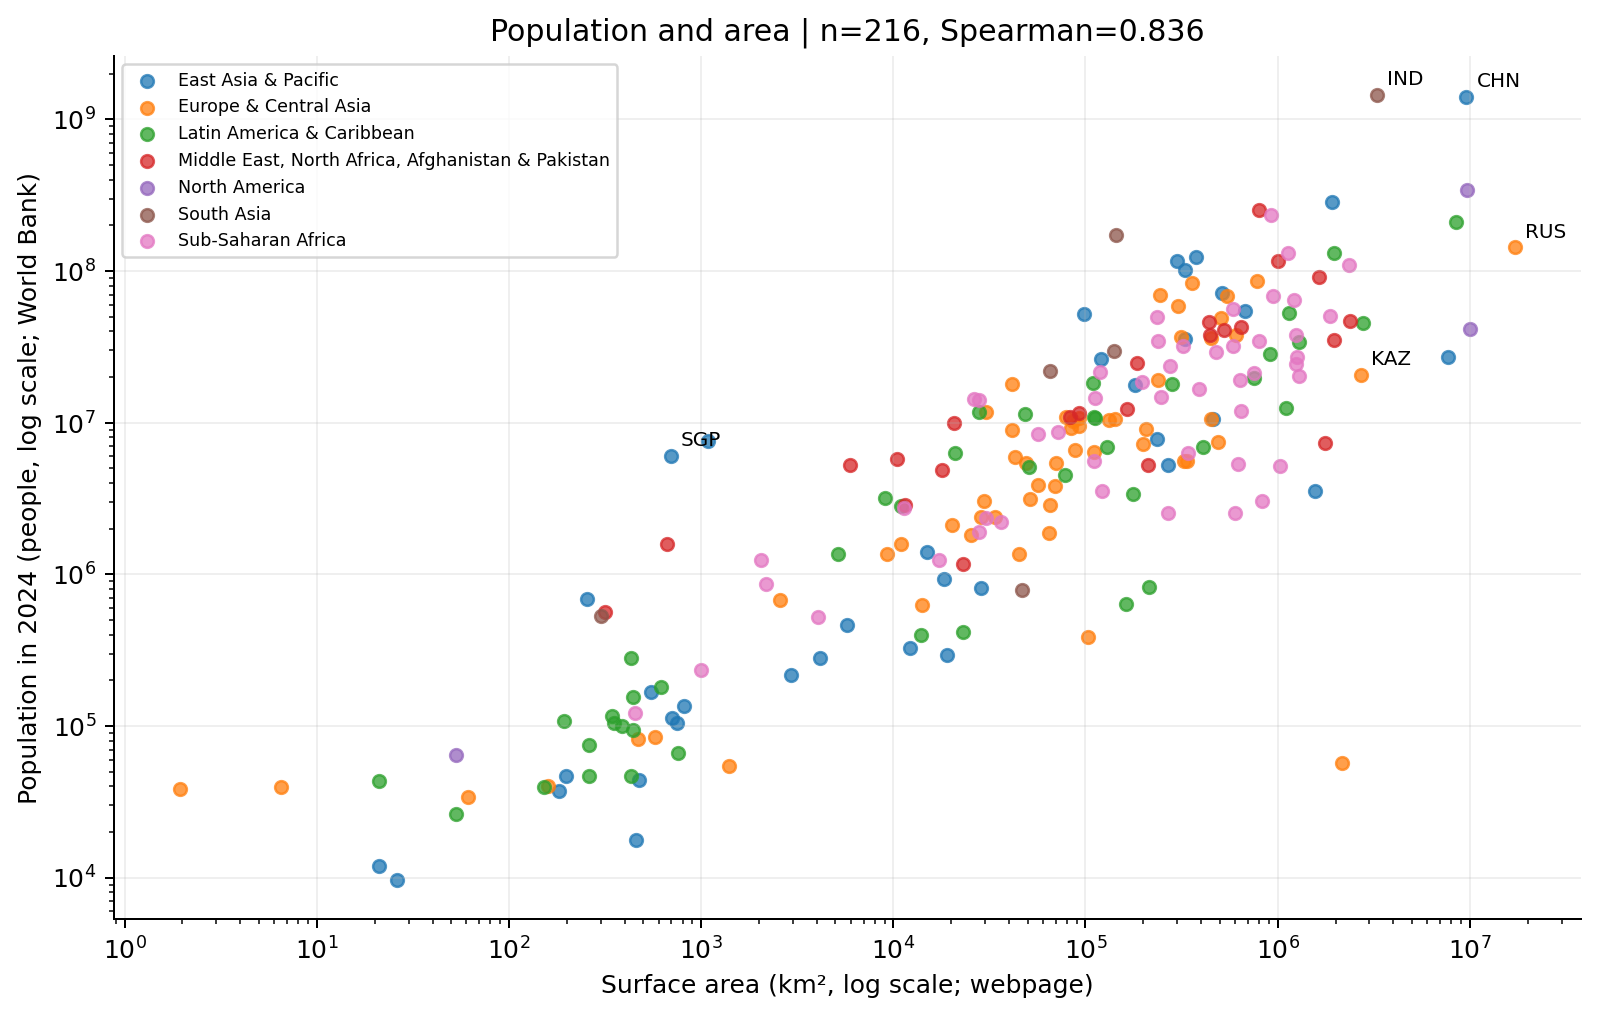

In [11]:
fig,ax = plt.subplots(figsize=(9,5.8))
for region, group in analysis.groupby("region",observed=True):
    ax.scatter(group["area_km2"].astype(float),group["population_2024"].astype(float),label=region,s=26,alpha=.75)
ax.set(xscale="log",yscale="log",xlabel="Surface area (km², log scale; webpage)",ylabel="Population in 2024 (people, log scale; World Bank)",title=f"Population and area | n={len(analysis)}, Spearman={spearman:.3f}")
ax.grid(which="major",alpha=.2);ax.legend(fontsize=7,loc="upper left")
for iso3 in ["IND","CHN","RUS","KAZ","SGP"]:
    row = analysis.loc[analysis["iso3"].eq(iso3)]
    if len(row):
        r=row.iloc[0];ax.annotate(iso3,(float(r["area_km2"]),float(r["population_2024"])),xytext=(4,4),textcoords="offset points",fontsize=8)
save_plot(fig,"03_population_vs_area.png")


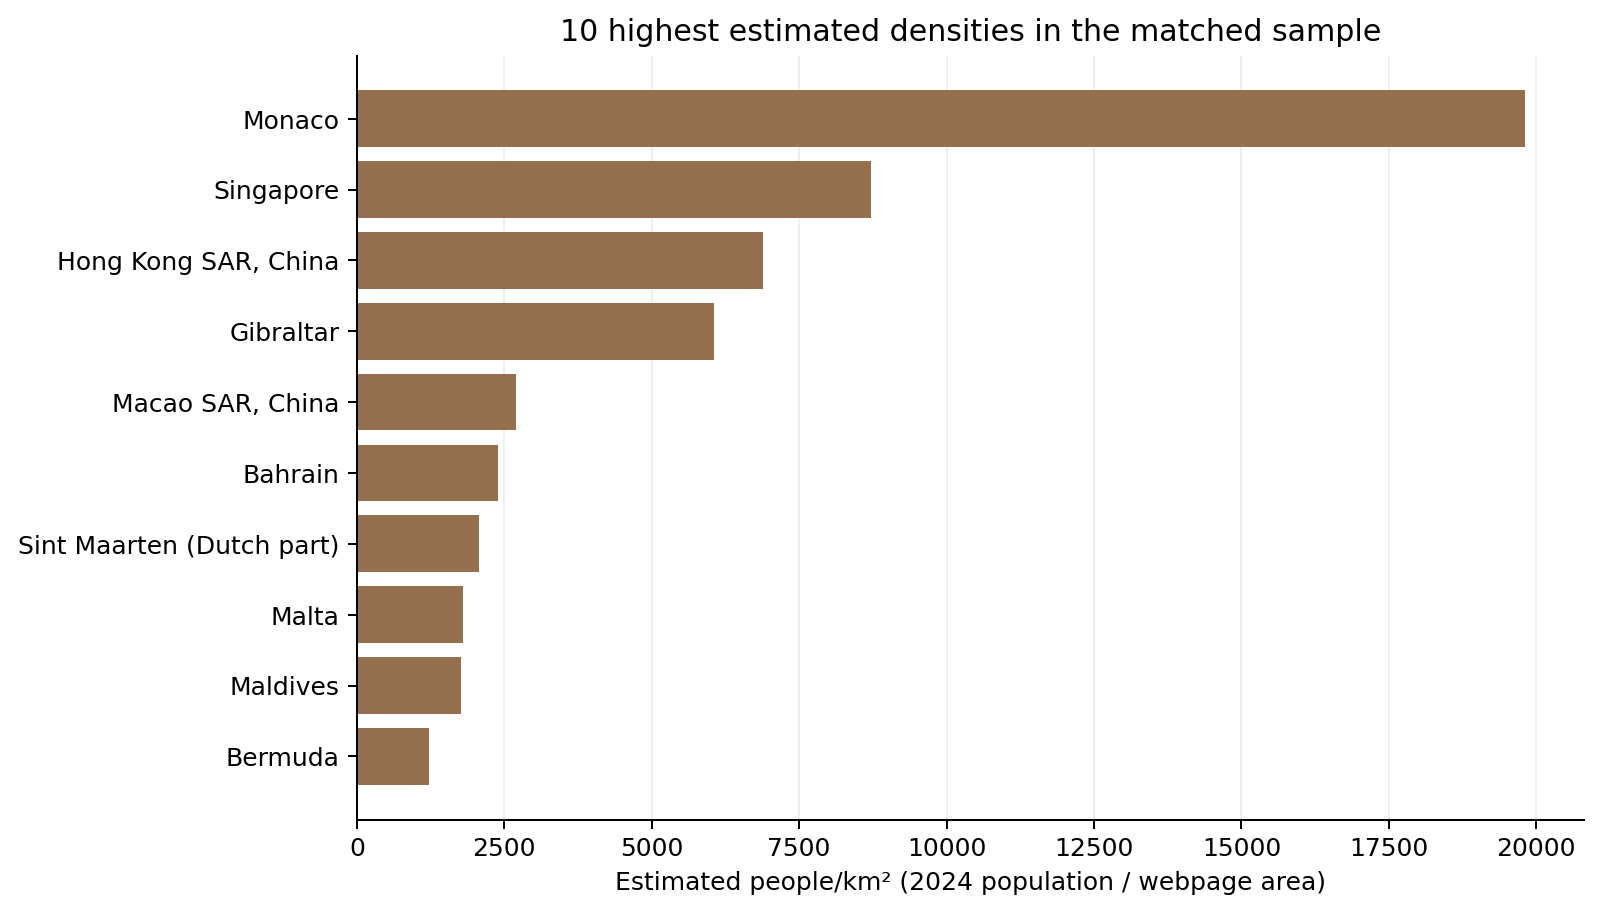

In [12]:
top_density = analysis.nlargest(10,"estimated_density").sort_values("estimated_density")
fig,ax = plt.subplots(figsize=(9,5.2))
ax.barh(top_density["country"],top_density["estimated_density"],color="#95704f")
ax.set(xlabel="Estimated people/km² (2024 population / webpage area)",title="10 highest estimated densities in the matched sample")
ax.grid(axis="x",alpha=.2);ax.set_axisbelow(True)
save_plot(fig,"04_top_estimated_density.png")


## 8. Computed findings and limitations

In [13]:
largest_pop = analysis.loc[analysis["population_2024"].idxmax()]
largest_area = analysis.loc[analysis["area_km2"].idxmax()]
densest = analysis.loc[analysis["estimated_density"].idxmax()]
kz = analysis.loc[analysis["iso3"].eq("KAZ")]
findings = [
    f"Coverage: {len(api_df)} API economies/territories and {len(web_df)} HTML records produce {len(merged)} code matches; {len(analysis)} positive-value rows are used for EDA.",
    f"Largest population in the matched sample: {largest_pop['country']}, {int(largest_pop['population_2024']):,} people in 2024.",
    f"Largest webpage surface area in the matched sample: {largest_area['country']}, {float(largest_area['area_km2']):,.0f} km².",
    f"Population-area correlations: raw Pearson {pearson:.3f}, Spearman {spearman:.3f}, log10 Pearson {log_pearson:.3f}. These are descriptive associations, not causation.",
    f"Highest approximate density in the matched sample: {densest['country']}, {float(densest['estimated_density']):,.1f} people/km². The area reference year is unknown."
]
if len(kz):
    r=kz.iloc[0];findings.append(f"Kazakhstan: {int(r['population_2024']):,} people (2024), {float(r['area_km2']):,.0f} km² (webpage), approximately {float(r['estimated_density']):.2f} people/km².")
for f in findings:print(f,"\n")
summary={"api_rows":len(api_df),"web_rows":len(web_df),"matched_rows":len(merged),"analysis_rows":len(analysis),"unmatched_api":int(audit['_merge'].eq('left_only').sum()),"unmatched_web":int(audit['_merge'].eq('right_only').sum()),"api_missing":int(api_df.isna().sum().sum()),"web_missing":int(web_df.isna().sum().sum()),"pearson":float(pearson),"spearman":float(spearman),"log_pearson":float(log_pearson),"findings":findings,"execution_utc":COLLECTED,"mode":"live" if LIVE else "offline","api_lastupdated":pop_header.get("lastupdated")}
(DATA/"summary.json").write_text(json.dumps(summary,ensure_ascii=False,indent=2),encoding="utf-8")
(DATA/"findings.txt").write_text("\n\n".join(findings),encoding="utf-8")


Coverage: 217 API economies/territories and 250 HTML records produce 216 code matches; 216 positive-value rows are used for EDA. 

Largest population in the matched sample: India, 1,450,935,791 people in 2024. 

Largest webpage surface area in the matched sample: Russian Federation, 17,100,000 km². 

Population-area correlations: raw Pearson 0.444, Spearman 0.836, log10 Pearson 0.869. These are descriptive associations, not causation. 

Highest approximate density in the matched sample: Monaco, 19,810.8 people/km². The area reference year is unknown. 

Kazakhstan: 20,592,571 people (2024), 2,717,300 km² (webpage), approximately 7.58 people/km². 

Out[13]: 647


### Interpretation and limitations
- This sample is the intersection of two sources. Missing territories and different country definitions affect coverage.
- Population is for **2024**. The HTML page does not give an area/population reference year; surface area may follow different boundary conventions. Density is an approximate mixed-source indicator.
- Country codes improve the join compared with names, but code semantics and differing territory coverage still require inspection. The unmatched-code table and name-pair table support this audit.
- Tiny territories can dominate density rankings. Large countries can strongly affect raw Pearson correlation; compare it with rank/log correlations.
- A missing capital is retained as missing. We do not impute a nonexistent capital. Rows are excluded only when a variable needed for the numerical analysis is missing or nonpositive.
- The webpage population field is collected and reviewed, but **the analytical population comes only from the dated World Bank API**.
- robots.txt was checked before scraping. API/page availability and structure can change. Snapshots enable reproducible offline reanalysis and are explicitly labeled.

## 9. Validation
Check unique codes, positive denominators, CSV round trips, plot files and snapshot provenance. CSV reading uses `keep_default_na=False` when auditing string codes so Namibia's code `NA` is not treated as a missing value.


In [14]:
assert not api_df["iso3"].duplicated().any()
assert not web_df["iso2"].duplicated().any()
assert not analysis["iso3"].duplicated().any()
assert analysis["area_km2"].gt(0).all() and analysis["population_2024"].gt(0).all()
assert analysis["estimated_density"].notna().all()
assert np.isfinite(analysis["estimated_density"].astype(float)).all()
assert -1<=pearson<=1 and -1<=spearman<=1 and -1<=log_pearson<=1
for filename,df in [("countries_api.csv",api_df),("countries_scraped.csv",web_df),("countries_merged.csv",merged),("countries_analysis.csv",analysis)]:
    reread=pd.read_csv(DATA/filename,keep_default_na=False)
    assert reread.shape==df.shape
    assert reread["iso2"].tolist()==df["iso2"].astype(str).tolist()
    print("CSV verified:",filename,reread.shape)
assert len(list(FIG.glob("*.png")))==4
print("All validation checks passed. Four plots and source snapshots are saved.")


CSV verified: countries_api.csv (217, 8)
CSV verified: countries_scraped.csv (250, 5)
CSV verified: countries_merged.csv (216, 12)
CSV verified: countries_analysis.csv (216, 17)
All validation checks passed. Four plots and source snapshots are saved.


## References
- World Bank V2 API documentation: https://datahelpdesk.worldbank.org/knowledgebase/articles/898581-api-basic-call-structures
- Country API documentation: https://datahelpdesk.worldbank.org/knowledgebase/articles/898590-country-api-queries
- Population indicator: https://data.worldbank.org/indicator/SP.POP.TOTL
- Scraped page: https://www.scrapethissite.com/pages/simple/
- Checked robots policy: https://www.scrapethissite.com/robots.txt

**Assistance note:** This project was prepared with AI assistance for code, analysis and explanatory materials. Review and understand every step before defense; ensure the report and visualization assistance matches the instructor's permission. No claim of unaided authorship is made.
